<a href="https://colab.research.google.com/github/sujata464/Ecommerce/blob/main/internship_prodify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0

Dataset size is about 1.14 GB. Please wait.
/content/leapgestre 100%[===================>]   2.13G   107MB/s    in 31s     

Download completed!

Extracting dataset...
Extraction completed!

Total images found: 40000
Valid images: 40000

Gesture classes:
01_palm = Palm
02_l = L Gesture
03_fist = Fist
04_fist_moved = Fist Moved
05_thumb = Thumb
06_index = Index
07_ok = OK
08_palm_moved = Palm Moved
09_c = C Gesture
10_down = Down

Dataset information:
                                               image    label
0  /content/leapgestrecog/leapgestrecog/leapGestR...  01_palm
1  /content/leapgestrecog/leapgestrecog/leapGestR...  01_palm
2  /content/leapgestrecog/leapgestrecog/leapGestR...  01_palm
3  /content/leapgestrecog/leapgestrecog/leapGestR...  01_palm
4  /content/leapgestrecog/leapgestrecog/leapGestR...  01_palm

Images per class:
label
01_palm          4000
09_c             4000
05_thumb         4000
02_l             4000
06_index         4000
10_down   

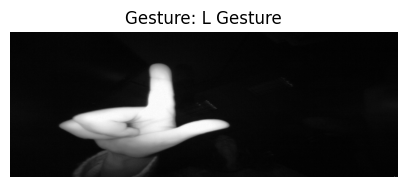


Model created successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,890 (17.50 MB)

 Trainable params: 4,585,930 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)


STARTING MODEL TRAINING
Epoch 1/5
 464/1000 ━━━━━━━━━━━━━━━━━━━━ 17:50 2s/step - accuracy: 0.6815 - loss: 1.6076

In [ ]:
# ================================================================
# PRODIGY INFOTECH - TASK 04
# HAND GESTURE RECOGNITION
# LeapGestRecog Dataset
# Complete Google Colab Code
# ================================================================

# ================================================================
# 1. INSTALL LIBRARIES
# ================================================================

!pip install -q tensorflow pandas numpy matplotlib pillow scikit-learn

# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import zipfile
import glob
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import files

print("TensorFlow version:", tf.__version__)

# ================================================================
# 3. DOWNLOAD DATASET
# ================================================================

print("\nDownloading LeapGestRecog dataset...")
print("Dataset size is about 1.14 GB. Please wait.")

dataset_url = "https://www.kaggle.com/api/v1/datasets/download/gti-upm/leapgestrecog"

zip_file = "/content/leapgestrecog.zip"

# Download using wget
!wget -q --show-progress -O /content/leapgestrecog.zip "$dataset_url"

print("\nDownload completed!")

# ================================================================
# 4. EXTRACT DATASET
# ================================================================

extract_path = "/content/leapgestrecog"

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

print("\nExtracting dataset...")

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

# ================================================================
# 5. FIND IMAGE FILES
# ================================================================

image_extensions = [
    "*.png",
    "*.jpg",
    "*.jpeg"
]

image_paths = []

for extension in image_extensions:
    image_paths.extend(
        glob.glob(
            extract_path + "/**/" + extension,
            recursive=True
        )
    )

print("\nTotal images found:", len(image_paths))

# ================================================================
# 6. GET GESTURE LABEL FROM FOLDER NAME
# ================================================================

gesture_names = {
    "01_palm": "Palm",
    "02_l": "L Gesture",
    "03_fist": "Fist",
    "04_fist_moved": "Fist Moved",
    "05_thumb": "Thumb",
    "06_index": "Index",
    "07_ok": "OK",
    "08_palm_moved": "Palm Moved",
    "09_c": "C Gesture",
    "10_down": "Down"
}

valid_paths = []
labels = []

for path in image_paths:

    folder = os.path.basename(
        os.path.dirname(path)
    )

    if folder in gesture_names:

        valid_paths.append(path)
        labels.append(folder)

print("Valid images:", len(valid_paths))

print("\nGesture classes:")

for key, value in gesture_names.items():
    print(key, "=", value)

# ================================================================
# 7. CREATE DATAFRAME
# ================================================================

data = pd.DataFrame({
    "image": valid_paths,
    "label": labels
})

print("\nDataset information:")
print(data.head())

print("\nImages per class:")
print(data["label"].value_counts())

# ================================================================
# 8. CONVERT LABELS TO NUMBERS
# ================================================================

class_list = sorted(
    data["label"].unique()
)

label_to_number = {
    label: index
    for index, label in enumerate(class_list)
}

number_to_label = {
    index: label
    for label, index in label_to_number.items()
}

data["label_number"] = data["label"].map(
    label_to_number
)

print("\nClass mapping:")

for number, label in number_to_label.items():

    print(
        number,
        "=",
        label,
        "=",
        gesture_names[label]
    )

# ================================================================
# 9. TRAIN / VALIDATION / TEST SPLIT
# ================================================================

train_data, temp_data = train_test_split(

    data,

    test_size=0.20,

    random_state=42,

    stratify=data["label_number"]
)

validation_data, test_data = train_test_split(

    temp_data,

    test_size=0.50,

    random_state=42,

    stratify=temp_data["label_number"]
)

print("\nDataset split:")

print(
    "Training:",
    len(train_data)
)

print(
    "Validation:",
    len(validation_data)
)

print(
    "Testing:",
    len(test_data)
)

# ================================================================
# 10. IMAGE SETTINGS
# ================================================================

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 5

# ================================================================
# 11. IMAGE LOADING FUNCTION
# ================================================================

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

# ================================================================
# 12. CREATE TF.DATA DATASETS
# ================================================================

def create_dataset(df, shuffle=False):

    paths = df["image"].values

    labels = df["label_number"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:

        dataset = dataset.shuffle(
            2000
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


train_ds = create_dataset(
    train_data,
    shuffle=True
)

validation_ds = create_dataset(
    validation_data
)

test_ds = create_dataset(
    test_data
)

# ================================================================
# 13. SHOW SAMPLE IMAGE
# ================================================================

sample_path = train_data.iloc[0]["image"]

sample_label = train_data.iloc[0]["label"]

sample_image = Image.open(
    sample_path
)

plt.figure(figsize=(5,5))

plt.imshow(
    sample_image,
    cmap="gray"
)

plt.title(
    "Gesture: " +
    gesture_names[sample_label]
)

plt.axis("off")

plt.show()

# ================================================================
# 14. CREATE CNN MODEL
# ================================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(IMG_SIZE, IMG_SIZE, 1)
    ),

    # First convolution block
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2,2)
    ),

    # Second convolution block
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2,2)
    ),

    # Third convolution block
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2,2)
    ),

    # Fourth convolution block
    tf.keras.layers.Conv2D(
        256,
        (3,3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2,2)
    ),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.4
    ),

    # Output layer
    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])

# ================================================================
# 15. COMPILE MODEL
# ================================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("\nModel created successfully!")

model.summary()

# ================================================================
# 16. CALLBACKS
# ================================================================

callbacks = [

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=2,

        restore_best_weights=True

    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=1

    )

]

# ================================================================
# 17. TRAIN MODEL
# ================================================================

print("\n======================================")
print("STARTING MODEL TRAINING")
print("======================================")

history = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)

print("\nTraining completed!")

# ================================================================
# 18. EVALUATE MODEL
# ================================================================

print("\n======================================")
print("MODEL EVALUATION")
print("======================================")

test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(
    "\nTest Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)

# ================================================================
# 19. ACCURACY GRAPH
# ================================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Hand Gesture Recognition Accuracy"
)

plt.legend()

plt.show()

# ================================================================
# 20. LOSS GRAPH
# ================================================================

plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Hand Gesture Recognition Loss"
)

plt.legend()

plt.show()

# ================================================================
# 21. CLASSIFICATION REPORT
# ================================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

y_true = []
y_pred = []

for images, labels_batch in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels_batch.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            gesture_names[number_to_label[i]]
            for i in range(10)
        ]
    )
)

# ================================================================
# 22. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.colorbar()

plt.xticks(
    range(10),
    [
        gesture_names[number_to_label[i]]
        for i in range(10)
    ],
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    [
        gesture_names[number_to_label[i]]
        for i in range(10)
    ]
)

plt.tight_layout()

plt.show()

# ================================================================
# 23. SAVE MODEL
# ================================================================

model_path = (
    "/content/hand_gesture_model.keras"
)

model.save(
    model_path
)

print(
    "\nModel saved:"
)

print(
    model_path
)

# ================================================================
# 24. SAVE CLASS LABELS
# ================================================================

label_file = (
    "/content/gesture_labels.csv"
)

label_df = pd.DataFrame({

    "number": list(
        number_to_label.keys()
    ),

    "folder": list(
        number_to_label.values()
    ),

    "gesture": [
        gesture_names[
            number_to_label[i]
        ]

        for i in range(10)
    ]

})

label_df.to_csv(
    label_file,
    index=False
)

print(
    "Labels saved:",
    label_file
)

# ================================================================
# 25. UPLOAD YOUR OWN HAND IMAGE
# ================================================================

print("\n======================================")
print("UPLOAD A HAND GESTURE IMAGE")
print("======================================")

uploaded = files.upload()

image_path = list(
    uploaded.keys()
)[0]

# ================================================================
# 26. LOAD UPLOADED IMAGE
# ================================================================

original_image = Image.open(
    image_path
).convert("L")

plt.figure(figsize=(6,5))

plt.imshow(
    original_image,
    cmap="gray"
)

plt.title(
    "Uploaded Hand Gesture"
)

plt.axis("off")

plt.show()

# ================================================================
# 27. PREPROCESS UPLOADED IMAGE
# ================================================================

input_image = original_image.resize(
    (IMG_SIZE, IMG_SIZE)
)

input_array = np.array(
    input_image
)

input_array = (
    input_array.astype(
        "float32"
    ) / 255.0
)

input_array = np.expand_dims(
    input_array,
    axis=-1
)

input_array = np.expand_dims(
    input_array,
    axis=0
)

# ================================================================
# 28. PREDICT GESTURE
# ================================================================

prediction = model.predict(
    input_array,
    verbose=0
)

predicted_index = np.argmax(
    prediction[0]
)

confidence = (
    prediction[0][predicted_index]
    * 100
)

predicted_folder = (
    number_to_label[
        predicted_index
    ]
)

predicted_gesture = (
    gesture_names[
        predicted_folder
    ]
)

# ================================================================
# 29. DISPLAY FINAL RESULT
# ================================================================

print("\n")
print("==========================================")
print("       HAND GESTURE RECOGNITION")
print("==========================================")

print(
    "Predicted Gesture:",
    predicted_gesture
)

print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)

print("==========================================")

# ================================================================
# 30. SHOW TOP 3 PREDICTIONS
# ================================================================

top_3 = np.argsort(
    prediction[0]
)[-3:][::-1]

print("\nTop 3 Predictions:")

for index in top_3:

    gesture = gesture_names[
        number_to_label[index]
    ]

    probability = (
        prediction[0][index] * 100
    )

    print(
        gesture,
        ":",
        round(
            probability,
            2
        ),
        "%"
    )

# ================================================================
# 31. SAVE PREDICTION RESULT
# ================================================================

prediction_result = pd.DataFrame({

    "Predicted_Gesture": [
        predicted_gesture
    ],

    "Confidence_Percentage": [
        round(
            confidence,
            2
        )
    ]

})

prediction_result.to_csv(
    "/content/prediction_result.csv",
    index=False
)

# ================================================================
# 32. FINAL PROJECT INFORMATION
# ================================================================

print("\n==========================================")
print("       PROJECT COMPLETED")
print("==========================================")

print("Project: Hand Gesture Recognition")

print(
    "Dataset: LeapGestRecog"
)

print(
    "Number of Classes: 10"
)

print(
    "Test Accuracy:",
    round(
        test_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Predicted Gesture:",
    predicted_gesture
)

print(
    "Confidence:",
    round(
        confidence,
        2
    ),
    "%"
)

print("\nFiles created:")

print(
    "1. hand_gesture_model.keras"
)

print(
    "2. gesture_labels.csv"
)

print(
    "3. prediction_result.csv"
)

print("\nTask-04 completed successfully!")